In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!kaggle competitions files -c iivp-2026-challenge
!kaggle competitions download -c iivp-2026-challenge
import zipfile
with zipfile.ZipFile('iivp-2026-challenge.zip', 'r') as zip_ref:
    zip_ref.extractall('./data')

Next Page Token = CfDJ8OqP5ZkTT9ZGj66XXRbxXyB0YiUT2mOpGu7DD4VQcRhKjiifaXrq-1D1g47rI0g-b19q70God7KUSMzBaDAxOpcUZ--f2Veg1aLf_n8EM0nGyUeWXFqEdkbtYFKnqSXrUhPT8a4p8fe5f1l9LqJJ
name                         size  creationDate                
---------------------  ----------  --------------------------  
sample_submission.csv          43  2026-04-09 16:18:34.435000  
test.csv                    17666  2026-04-09 16:18:34.598000  
test/test/10002.png           636  2026-04-09 16:18:39.965000  
test/test/10015.png           629  2026-04-09 16:18:39.393000  
test/test/10021.png           621  2026-04-09 16:18:37.041000  
test/test/10037.png           642  2026-04-09 16:18:37.594000  
test/test/10040.png           671  2026-04-09 16:18:35.502000  
test/test/10041.png           682  2026-04-09 16:18:35.511000  
test/test/10045.png           657  2026-04-09 16:18:35.908000  
test/test/10046.png           694  2026-04-09 16:18:36.386000  
test/test/10056.png           663  2026-04-09 16:18:35.070000

In [3]:
import os

# List everything in your current 'Output' directory
for dirname, _, filenames in os.walk('/kaggle/working'):
    print(f"Found directory: {dirname}")
    # Print the first 2 files in each folder to verify
    if filenames:
        print(f"Sample files: {filenames[:2]}")

Found directory: /kaggle/working
Sample files: ['iivp-2026-challenge.zip', '__notebook__.ipynb']
Found directory: /kaggle/working/data
Sample files: ['train.csv', 'test.csv']
Found directory: /kaggle/working/data/test
Found directory: /kaggle/working/data/test/test
Sample files: ['29535.png', '40925.png']
Found directory: /kaggle/working/data/train
Found directory: /kaggle/working/data/train/train
Found directory: /kaggle/working/data/train/train/0
Sample files: ['76349.png', '4603.png']
Found directory: /kaggle/working/data/train/train/3
Sample files: ['71248.png', '5163.png']
Found directory: /kaggle/working/data/train/train/5
Sample files: ['53190.png', '77859.png']
Found directory: /kaggle/working/data/train/train/4
Sample files: ['77406.png', '53156.png']
Found directory: /kaggle/working/data/train/train/8
Sample files: ['22915.png', '68479.png']
Found directory: /kaggle/working/data/train/train/2
Sample files: ['9722.png', '66892.png']
Found directory: /kaggle/working/data/train/

In [4]:
import os

print(os.listdir('/kaggle/working'))

['data', 'iivp-2026-challenge.zip', '__notebook__.ipynb']


In [5]:
import zipfile
import os

with zipfile.ZipFile('/kaggle/working/iivp-2026-challenge.zip', 'r') as zip_ref:
    zip_ref.extractall('/kaggle/working/data')

In [6]:
print(os.listdir('/kaggle/working/data'))


['train.csv', 'test.csv', 'sample_submission.csv', 'test', 'train']


In [7]:

train_df = pd.read_csv('/kaggle/working/data/train.csv')
test_df  = pd.read_csv('/kaggle/working/data/test.csv')

print(train_df.head(10))
print(f"\nTrain size: {len(train_df)}")
print(f"Test size:  {len(test_df)}")
print(f"\nTrain columns: {train_df.columns.tolist()}")
print(f"Test columns:  {test_df.columns.tolist()}")


      Id  Category
0   7168         6
1   9876         3
2  78117         6
3   9626         1
4  29492         3
5  76947         2
6  40828         4
7  56277         2
8   7414         9
9   5468         5

Train size: 17000
Test size:  3000

Train columns: ['Id', 'Category']
Test columns:  ['Id']


In [8]:
# Check image folder contents
print(os.listdir('/kaggle/working/data/train/train/0')[:10])
print(os.listdir('/kaggle/working/data/test/test')[:10])

['76349.png', '4603.png', '28819.png', '39548.png', '49219.png', '39513.png', '28839.png', '28954.png', '66607.png', '28952.png']
['29535.png', '40925.png', '41232.png', '50903.png', '67825.png', '78531.png', '43696.png', '41017.png', '5527.png', '41114.png']


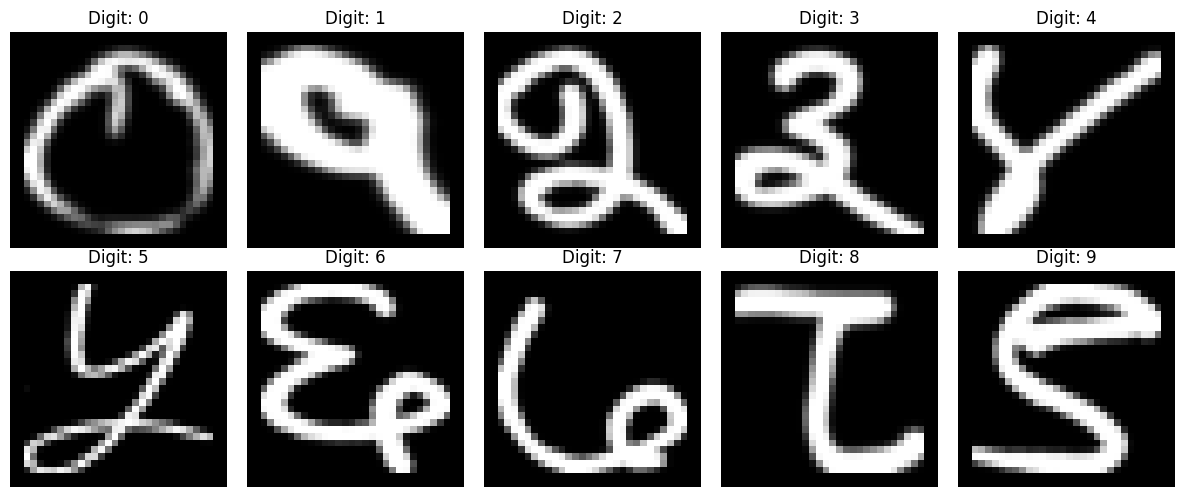

Image size: (32, 32)
Image mode: L


In [9]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit in range(10):
    sample = train_df[train_df['Category'] == digit].iloc[0]
    img = Image.open(f"/kaggle/working/data/train/train/{digit}/{sample['Id']}.png")
    axes[digit // 5][digit % 5].imshow(img, cmap='gray')
    axes[digit // 5][digit % 5].set_title(f"Digit: {digit}")
    axes[digit // 5][digit % 5].axis('off')
plt.tight_layout()
plt.show()

sample_img = Image.open(f"/kaggle/working/data/train/train/6/{train_df.iloc[0]['Id']}.png")
print(f"Image size: {sample_img.size}")
print(f"Image mode: {sample_img.mode}")

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import timm

# --- Dataset ---
class DigitDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, has_labels=True):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.has_labels = has_labels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        if self.has_labels:
            img_path = f"{self.img_dir}/{row['Category']}/{row['Id']}.png"
        else:
            # for test images we don't know the category subfolder
            # so we search for the file
            img_path = f"{self.img_dir}/{row['Id']}.png"
        img = Image.open(img_path).convert('L')
        if self.transform:
            img = self.transform(img)
        if self.has_labels:
            return img, int(row['Category'])
        return img, row['Id']

# --- Transforms ---
transform_train = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# --- Split ---
train_split, val_split = train_test_split(
    train_df, test_size=0.2, stratify=train_df['Category'], random_state=42
)

TRAIN_IMG_DIR = '/kaggle/working/data/train/train'

train_dataset = DigitDataset(train_split, TRAIN_IMG_DIR, transform_train)
val_dataset   = DigitDataset(val_split,   TRAIN_IMG_DIR, transform_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=2)

# --- Model ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=10, in_chans=1)
model = model.to(device)

# --- Training ---
optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=20)
criterion = nn.CrossEntropyLoss()

best_acc = 0
for epoch in range(10):
    # Train
    model.train()
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
    scheduler.step()

    # Validate
    model.eval()
    correct = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()

    acc = correct / len(val_split)
    print(f"Epoch {epoch+1:02d}/20 — Val Acc: {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), '/kaggle/working/best_model.pth')

print(f"\nBest Val Accuracy: {best_acc:.4f}")

Using device: cpu


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Epoch 01/20 — Val Acc: 0.9621
Epoch 02/20 — Val Acc: 0.9841
Epoch 03/20 — Val Acc: 0.9900
Epoch 04/20 — Val Acc: 0.9926
Epoch 05/20 — Val Acc: 0.9953
Epoch 06/20 — Val Acc: 0.9944
Epoch 07/20 — Val Acc: 0.9959
Epoch 08/20 — Val Acc: 0.9968
Epoch 09/20 — Val Acc: 0.9968
Epoch 10/20 — Val Acc: 0.9979

Best Val Accuracy: 0.9979


In [11]:
import glob

# Build a lookup: Id -> file path for test images
test_files = glob.glob('/kaggle/working/data/test/test/**/*.png', recursive=True)
test_lookup = {os.path.splitext(os.path.basename(f))[0]: f for f in test_files}

# Dataset for test images
class TestDataset(Dataset):
    def __init__(self, df, lookup, transform):
        self.df = df.reset_index(drop=True)
        self.lookup = lookup
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.lookup[str(row['Id'])]).convert('L')
        if self.transform:
            img = self.transform(img)
        return img, row['Id']

test_dataset = TestDataset(test_df, test_lookup, transform_val)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

# Load best model and predict
model.load_state_dict(torch.load('/kaggle/working/best_model.pth'))
model.eval()

ids, preds = [], []
with torch.no_grad():
    for imgs, file_ids in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs).argmax(dim=1).cpu().numpy()
        ids.extend(file_ids.numpy())
        preds.extend(outputs)

# Save submission
submission = pd.DataFrame({'Id': ids, 'Category': preds})
submission.to_csv('/kaggle/working/submission.csv', index=False)
print(f"Submission saved! Shape: {submission.shape}")
print(submission.head(10))

Submission saved! Shape: (3000, 2)
      Id  Category
0  56604         6
1  29396         3
2  43803         6
3  12313         0
4  10341         8
5  40355         3
6  41117         4
7  71324         7
8   6854         1
9  12761         8
